In [ ]:
%load_ext autoreload
%autoreload 2
import os
os.environ["USE_PYGEOS"] = "0"

import h5py
from pathlib import Path
import numpy as np
import pandas as pd
import spatialdata as sd
import scanpy as sc
from scipy.sparse import issparse
# import functions
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas
import spatialdata
import spatialdata_plot
import sparrow as sp
import geopandas

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribut

In [2]:
sdata_polyT = sd.read_zarr('../data/vizgen_polyT_45056_solved/')

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/tmp/ipykernel_52360/4116733535.py:1: DeprecationWarning: Table group found in zarr store at location /home/chananchidas/visium-hd/data/vizgen_polyT_45056_solved. Please update the zarr store to use tables instead.
  sdata_polyT = sd.read_zarr('../data/vizgen_polyT_45056_solved/')


In [3]:
crd=[10000,15000,8000,12000]

In [4]:
sdata_polyT

SpatialData object, with associated Zarr store: /home/chananchidas/visium-hd/data/vizgen_polyT_45056_solved
├── Images
│     ├── 'clahe': DataArray[cyx] (1, 45056, 45056)
│     ├── 'raw_image': DataArray[cyx] (1, 45056, 45056)
│     └── 'tophat_filtered': DataArray[cyx] (1, 45056, 45056)
├── Labels
│     ├── 'grid_8um_labels': DataArray[yx] (45056, 45056)
│     ├── 'grid_16um_labels': DataArray[yx] (45056, 45056)
│     ├── 'grid_32um_labels': DataArray[yx] (45056, 45056)
│     └── 'segmentation_mask': DataArray[yx] (45056, 45056)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 3) (2D points)
├── Shapes
│     ├── 'filtered_low_counts_segmentation_mask_boundaries': GeoDataFrame shape: (5, 1) (2D shapes)
│     ├── 'filtered_segmentation_mask_boundaries_low_counts': GeoDataFrame shape: (5409, 1) (2D shapes)
│     ├── 'filtered_segmentation_mask_boundaries_segmentation': GeoDataFrame shape: (3080, 1) (2D shapes)
│     ├── 'filtered_segmentation_mask_boundaries_size': G

In [ ]:
from shapely.affinity import scale

# Flip the y-coordinates of the geometries in the segmentation_mask_boundaries
flipped_segmentation = sdata_polyT.shapes['segmentation_mask_boundaries']['geometry'].apply(
    lambda geom: scale(geom, xfact=1, yfact=-1, origin=(0, 0))
)

# Save the flipped geometries to a file
flipped_segmentation.to_file('../visium_hd_liver_combined/vizgen/segmentation_mask_boundaries.shp')

/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/pyogrio/geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [ ]:
sc.pl.umap(sdata_polyT.tables['table'],color='annotation_own_score_genes')

In [4]:
# Proportion of cell types
sdata_polyT.table.obs['annotation_own_score_genes'].value_counts(normalize=True)

/tmp/ipykernel_30717/3062927515.py:2: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  sdata_polyT.table.obs['annotation_own_score_genes'].value_counts(normalize=True)


annotation_own_score_genes
Hepatocytes          0.682303
Endothelial cells    0.107116
Stromal cells        0.063157
Unknown              0.055699
Kuppfer cells        0.043603
Other immunecells    0.025049
Cholangiocytes       0.013388
B cells              0.009685
Name: proportion, dtype: float64

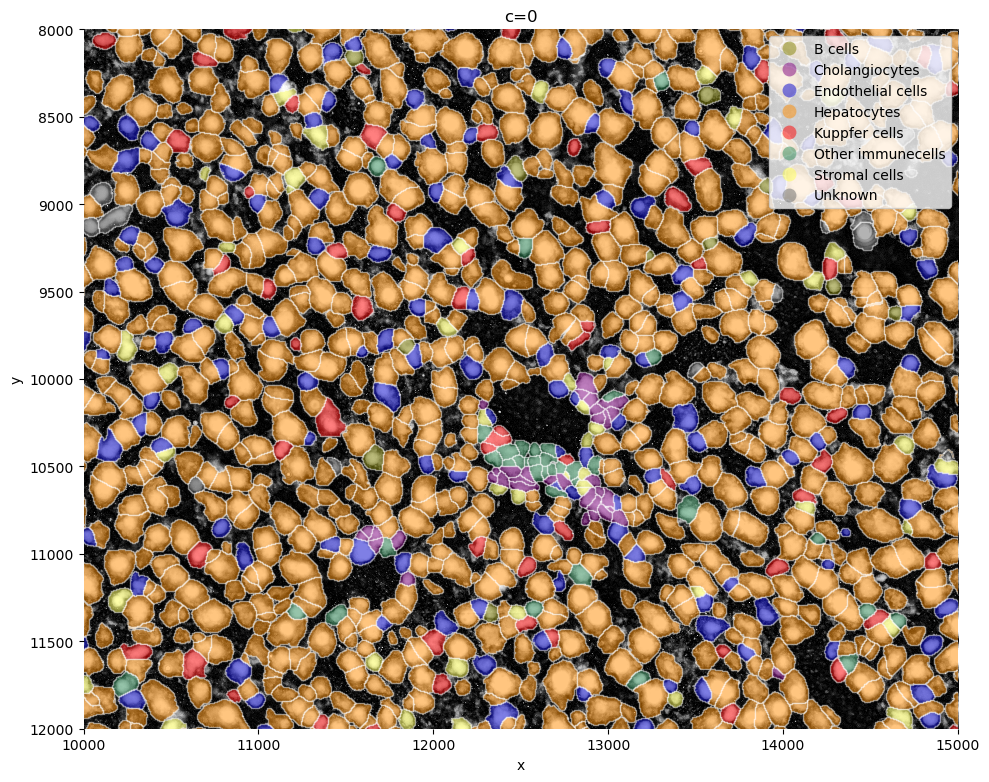

In [ ]:
sp.pl.plot_shapes(sdata_polyT,crd=crd,
                  figsize=(10,10),
                  column='annotation_own_score_genes',
                  alpha=0.5,
                  shapes_layer='segmentation_mask_boundaries',
                  img_layer='clahe',
                  table_layer='table')

Save the original annotation and cells by Sparrow. Used mainly to calculate the cell type proportions obtained from Sparrow.

In [ ]:
sdata_polyT.table.obs[['total_counts', 'n_genes_by_counts', 'annotation_own_score_genes', 'shapeSize']].to_csv('../visium_hd_liver_combined/vizgen/sdata_polyT_obs.csv')

/tmp/ipykernel_12501/1724686162.py:1: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  sdata_polyT.table.obs[['total_counts', 'n_genes_by_counts', 'annotation_own_score_genes', 'shapeSize']].to_csv('../visium_hd_liver_combined/vizgen/sdata_polyT_obs.csv')


### Create grid in Vizgen data

In [ ]:
# 1 pixel = 108nm
bin_size = 8 # 8,16,32
grid_size = bin_size*1000/108

In [5]:
# take shape of grid equal to image
se = sdata_polyT["raw_image"]
sdata_polyT = sp.im.add_grid_labels_layer(sdata_polyT, shape = se.shape[1:], size=grid_size, output_shapes_layer=f"grid_{bin_size}um",
                                    output_labels_layer=f"grid_{bin_size}um_labels", grid_type="square", overwrite=True,
                                    chunks=256)

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
2025-10-13 10:45:59,005 - sparrow.image._manager - WARNING - No dims parameter specified. Assuming order of dimension of provided array is ((c), (z), y, x)
2025-10-13 10:45:59,047 - sparrow.image._manager - INFO - Writing results to layer 'grid_4um_labels'


In [6]:
# See grid polygons
sdata_polyT.shapes[f'grid_{bin_size}um']

,geometry
1,"POLYGON ((0 0, 37.037 0, 37.037 37.037, 0 37.0..."
2,"POLYGON ((37.037 0, 74.074 0, 74.074 37.037, 3..."
3,"POLYGON ((74.074 0, 111.111 0, 111.111 37.037,..."
4,"POLYGON ((111.111 0, 148.148 0, 148.148 37.037..."
5,"POLYGON ((148.148 0, 185.185 0, 185.185 37.037..."
...,...
1478652,"POLYGON ((44851.852 45000, 44888.889 45000, 44..."
1478653,"POLYGON ((44888.889 45000, 44925.926 45000, 44..."
1478654,"POLYGON ((44925.926 45000, 44962.963 45000, 44..."
1478655,"POLYGON ((44962.963 45000, 45000 45000, 45000 ..."


In [7]:
# Save grid (for R)
from shapely.affinity import scale

# Flip the y-coordinates of the geometries
flipped_geometry = sdata_polyT.shapes[f'grid_{bin_size}um']['geometry'].apply(lambda geom: scale(geom, xfact=1, yfact=-1, origin=(0, 0)))

# Save the flipped shapes
flipped_geometry.to_file(f'../visium_hd_liver_combined/vizgen/grid_{bin_size}um.shp')

Here, we will get the intersection between the grid and the segmented cells.

In [8]:
# Segmentation shapes
segmentation = sdata_polyT.shapes['segmentation_mask_boundaries']
segmentation['segmentation_id'] = segmentation.index

# Get grid shapes from sdata, and add grid_id to the grid shapes
grid_df = sdata_polyT.shapes[f'grid_{bin_size}um']
grid_df['grid_id'] = grid_df.index

In [ ]:
# For visualization in R - save centroids
# Calculate centroids of grid_df geometry
grid_df['centroid'] = grid_df.geometry.centroid

# Extract x and y coordinates of the centroids
grid_df['centroid_x'] = grid_df['centroid'].x
grid_df['centroid_y'] = grid_df['centroid'].y

# Save grid_df
grid_df[['grid_id', 'centroid_x', 'centroid_y']].to_csv(f'../visium_hd_liver_combined/vizgen/vizgen_grid{bin_size}um_centroids.csv', index=False)

In [10]:
# Use overlay to get intersection geometry
intersection_result = geopandas.overlay(grid_df, segmentation, how='intersection')
intersection_result = intersection_result.rename(columns={"geometry": "intersecting_geometry"})

# Add original grid_geometry
# intersection_result["grid_geometry"] = grid_df.loc[intersection_result["grid_id"]].geometry.values

# Add original segmentation geometry and id
intersection_result["segmentation_geometry"] = segmentation.loc[intersection_result["segmentation_id"]].geometry.values
intersection_result

,grid_id,segmentation_id,intersecting_geometry,segmentation_geometry
0,628,2114,"POLYGON ((23259.259 37.037, 23259.259 16, 2325...","MULTIPOLYGON (((23264 10, 23267 10, 23267 11, ..."
1,629,2114,"POLYGON ((23259.259 37.037, 23296.296 37.037, ...","MULTIPOLYGON (((23264 10, 23267 10, 23267 11, ..."
2,630,2114,"POLYGON ((23296.296 37.037, 23317 37.037, 2331...","MULTIPOLYGON (((23264 10, 23267 10, 23267 11, ..."
3,636,1922,"POLYGON ((23555.556 3, 23554 3, 23554 4, 23553...","MULTIPOLYGON (((23588 152, 23588 153, 23590 15..."
4,637,1922,"POLYGON ((23592.593 37.037, 23592.593 6, 23591...","MULTIPOLYGON (((23588 152, 23588 153, 23590 15..."
...,...,...,...,...
1289436,1478650,54883,"POLYGON ((44777.778 45000, 44777.778 45037.037...","MULTIPOLYGON (((44756 44931, 44770 44931, 4477..."
1289437,1478650,56291,"POLYGON ((44814.815 45037.037, 44814.815 45000...","MULTIPOLYGON (((44799 44970, 44800 44970, 4480..."
1289438,1478651,56291,"POLYGON ((44814.815 45037.037, 44851.852 45037...","MULTIPOLYGON (((44799 44970, 44800 44970, 4480..."
1289439,1478652,56291,"POLYGON ((44851.852 45000, 44851.852 45037.037...","MULTIPOLYGON (((44799 44970, 44800 44970, 4480..."


In [11]:
# Extract the counts and annotation from sdata
cell_metadata = sdata_polyT.table.obs[['total_counts', 'annotation_own_score_genes']]

# Merge the counts with segmentation_id
intersection_result = intersection_result.merge(cell_metadata, left_on='segmentation_id', right_index=True, how='left')

intersection_result.head()

,grid_id,segmentation_id,intersecting_geometry,segmentation_geometry,total_counts,annotation_own_score_genes
0,628,2114,"POLYGON ((23259.259 37.037, 23259.259 16, 2325...","MULTIPOLYGON (((23264 10, 23267 10, 23267 11, ...",288,Unknown
1,629,2114,"POLYGON ((23259.259 37.037, 23296.296 37.037, ...","MULTIPOLYGON (((23264 10, 23267 10, 23267 11, ...",288,Unknown
2,630,2114,"POLYGON ((23296.296 37.037, 23317 37.037, 2331...","MULTIPOLYGON (((23264 10, 23267 10, 23267 11, ...",288,Unknown
3,636,1922,"POLYGON ((23555.556 3, 23554 3, 23554 4, 23553...","MULTIPOLYGON (((23588 152, 23588 153, 23590 15...",219,Unknown
4,637,1922,"POLYGON ((23592.593 37.037, 23592.593 6, 23591...","MULTIPOLYGON (((23588 152, 23588 153, 23590 15...",219,Unknown


In [12]:
# Calculate the area of intersecting_geometry and segmentation_geometry
intersection_result['intersecting_area'] = intersection_result['intersecting_geometry'].area
intersection_result['segmentation_area'] = intersection_result['segmentation_geometry'].area

# Calculate the percentage of intersecting area over segmentation area
intersection_result['intersecting_area_frac'] = (
    intersection_result['intersecting_area'] / intersection_result['segmentation_area']
)

# Calculate the percentage of counts over total_counts
intersection_result['counts_frac'] = (
    intersection_result['intersecting_area_frac'] * intersection_result['total_counts']
)

intersection_result

,grid_id,segmentation_id,intersecting_geometry,segmentation_geometry,total_counts,annotation_own_score_genes,intersecting_area,segmentation_area,intersecting_area_frac,counts_frac
0,628,2114,"POLYGON ((23259.259 37.037, 23259.259 16, 2325...","MULTIPOLYGON (((23264 10, 23267 10, 23267 11, ...",288,Unknown,176.157750,16244.0,0.010844,3.123211
1,629,2114,"POLYGON ((23259.259 37.037, 23296.296 37.037, ...","MULTIPOLYGON (((23264 10, 23267 10, 23267 11, ...",288,Unknown,711.890261,16244.0,0.043825,12.621546
2,630,2114,"POLYGON ((23296.296 37.037, 23317 37.037, 2331...","MULTIPOLYGON (((23264 10, 23267 10, 23267 11, ...",288,Unknown,141.803841,16244.0,0.008730,2.514129
3,636,1922,"POLYGON ((23555.556 3, 23554 3, 23554 4, 23553...","MULTIPOLYGON (((23588 152, 23588 153, 23590 15...",219,Unknown,114.888889,19093.0,0.006017,1.317795
4,637,1922,"POLYGON ((23592.593 37.037, 23592.593 6, 23591...","MULTIPOLYGON (((23588 152, 23588 153, 23590 15...",219,Unknown,1256.762689,19093.0,0.065823,14.415285
...,...,...,...,...,...,...,...,...,...,...
1289436,1478650,54883,"POLYGON ((44777.778 45000, 44777.778 45037.037...","MULTIPOLYGON (((44756 44931, 44770 44931, 4477...",925,Hepatocytes,136.378601,8159.0,0.016715,15.461479
1289437,1478650,56291,"POLYGON ((44814.815 45037.037, 44814.815 45000...","MULTIPOLYGON (((44799 44970, 44800 44970, 4480...",461,Cholangiocytes,1235.363512,7922.0,0.155941,71.888738
1289438,1478651,56291,"POLYGON ((44814.815 45037.037, 44851.852 45037...","MULTIPOLYGON (((44799 44970, 44800 44970, 4480...",461,Cholangiocytes,1371.742112,7922.0,0.173156,79.824932
1289439,1478652,56291,"POLYGON ((44851.852 45000, 44851.852 45037.037...","MULTIPOLYGON (((44799 44970, 44800 44970, 4480...",461,Cholangiocytes,1363.075446,7922.0,0.172062,79.320598


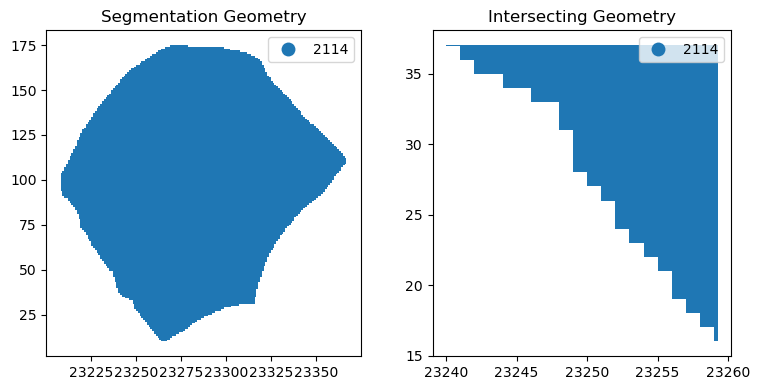

In [13]:
first_grid_id = intersection_result['grid_id'].unique()[0]
# Make sure the segmentation and intersecting geometry plots look correct
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Plot segmentation geometry
intersection_result[intersection_result['grid_id'] == first_grid_id].set_geometry('segmentation_geometry').plot(
    column='segmentation_id', cmap='tab20', legend=True, ax=axes[0]
)
axes[0].set_title('Segmentation Geometry')

# Plot intersecting geometry
intersection_result[intersection_result['grid_id'] == first_grid_id].set_geometry('intersecting_geometry').plot(
    column='segmentation_id', cmap='tab20', legend=True, ax=axes[1]
)
axes[1].set_title('Intersecting Geometry')

plt.tight_layout()

As you see, the `intersection_result` dataframe contains for each grid, the intersecting cell(s) and the originating cell. This is so that we can calculate the fraction of counts that the intersected cell contains. So if 30\% of the cell is in a grid, we assume that it contains 30\% of the counts of that cell. This assumption may not always hold true but for ease of computation we consider it true over the whole area.

<Axes: >

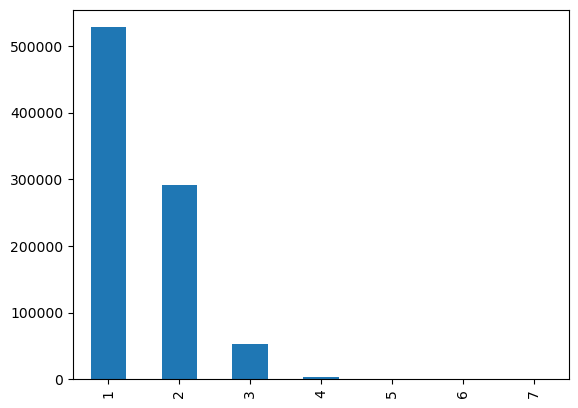

In [14]:
# What is the number of cells in each grid?
# Plot barplot of intersections.grid_id.value_counts()
cells_per_grid = intersection_result.grid_id.value_counts()
cells_per_grid = cells_per_grid.groupby(cells_per_grid.values).count()
cells_per_grid.plot(kind="bar")

In [15]:
# Save intersection result (without the geometries)
intersection_result_clean = intersection_result.drop(columns=['intersecting_geometry', 'segmentation_geometry'])
intersection_result_clean.to_csv(f'../visium_hd_liver_combined/vizgen/intersection_result_{bin_size}um.csv', index=False)

Now we can transform the dataframe into a proportion matrix (grid_id $\times$ celltype), based on the number of counts.

In [16]:
# Group by grid_id and cell type, summing counts_frac
grid_celltype_counts = intersection_result.groupby(['grid_id', 'annotation_own_score_genes'])['counts_frac'].sum().reset_index()

# Calculate the total counts_frac per grid_id
total_counts_per_grid = grid_celltype_counts.groupby('grid_id')['counts_frac'].sum().reset_index()
total_counts_per_grid.rename(columns={'counts_frac': 'total_counts_frac'}, inplace=True)

# Merge total counts back to the grouped data
grid_celltype_counts = grid_celltype_counts.merge(total_counts_per_grid, on='grid_id')

# Calculate the proportion of counts for each cell type within each grid
grid_celltype_counts['proportion'] = grid_celltype_counts['counts_frac'] / grid_celltype_counts['total_counts_frac']

# Pivot the dataframe to have grid_id as rows and cell types as columns
grid_celltype_proportion = grid_celltype_counts.pivot(index='grid_id', columns='annotation_own_score_genes', values='proportion').fillna(0)

grid_celltype_proportion

annotation_own_score_genes,B cells,Cholangiocytes,Endothelial cells,Hepatocytes,Kuppfer cells,Other immunecells,Stromal cells,Unknown
grid_id,,,,,,,,
628,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,1.0
629,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,1.0
630,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,1.0
636,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,1.0
637,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
1478649,0.0,0.000000,0.0,1.000000,0.0,0.0,0.0,0.0
1478650,0.0,0.822994,0.0,0.177006,0.0,0.0,0.0,0.0
1478651,0.0,1.000000,0.0,0.000000,0.0,0.0,0.0,0.0


In [17]:
# Save grid_celltype_proportion
grid_celltype_proportion.to_csv(f'../visium_hd_liver_combined/vizgen/vizgen_grid_{bin_size}um_celltype_proportions.csv')

It might also be interesting to calculate the cell type proportions based on the area of the cells, instead of the counts.

In [18]:
# Group by grid_id and cell type, summing intersecting_area
grid_celltype_area = intersection_result.groupby(['grid_id', 'annotation_own_score_genes'])['intersecting_area'].sum().reset_index()

# Calculate the total intersecting_area per grid_id
total_area_per_grid = grid_celltype_area.groupby('grid_id')['intersecting_area'].sum().reset_index()
total_area_per_grid.rename(columns={'intersecting_area': 'total_area'}, inplace=True)

# Merge total area back to the grouped data
grid_celltype_area = grid_celltype_area.merge(total_area_per_grid, on='grid_id')

# Calculate the proportion of area for each cell type within each grid
grid_celltype_area['proportion'] = grid_celltype_area['intersecting_area'] / grid_celltype_area['total_area']

# Pivot the dataframe to have grid_id as rows and cell types as columns
grid_celltype_area_proportion = grid_celltype_area.pivot(index='grid_id', columns='annotation_own_score_genes', values='proportion').fillna(0)

grid_celltype_area_proportion

annotation_own_score_genes,B cells,Cholangiocytes,Endothelial cells,Hepatocytes,Kuppfer cells,Other immunecells,Stromal cells,Unknown
grid_id,,,,,,,,
628,0.0,0.00000,0.0,0.00000,0.0,0.0,0.0,1.0
629,0.0,0.00000,0.0,0.00000,0.0,0.0,0.0,1.0
630,0.0,0.00000,0.0,0.00000,0.0,0.0,0.0,1.0
636,0.0,0.00000,0.0,0.00000,0.0,0.0,0.0,1.0
637,0.0,0.00000,0.0,0.00000,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
1478649,0.0,0.00000,0.0,1.00000,0.0,0.0,0.0,0.0
1478650,0.0,0.90058,0.0,0.09942,0.0,0.0,0.0,0.0
1478651,0.0,1.00000,0.0,0.00000,0.0,0.0,0.0,0.0


In [19]:
# Save grid_celltype_area_proportion
grid_celltype_area_proportion.to_csv(f'../visium_hd_liver_combined/vizgen/vizgen_grid_{bin_size}um_celltype_proportions_by_area.csv')

#### Visualization in a ROI

In [4]:
sdata_small = sdata_polyT.query.bounding_box(
    min_coordinate=[crd[0], crd[2]], max_coordinate=[crd[1], crd[3]], axes=("x", "y"), target_coordinate_system="global"
)

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/functools.py:889: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


In [21]:
sdata_small

SpatialData object
├── Images
│     ├── 'clahe': DataArray[cyx] (1, 4000, 5000)
│     ├── 'raw_image': DataArray[cyx] (1, 4000, 5000)
│     └── 'tophat_filtered': DataArray[cyx] (1, 4000, 5000)
├── Labels
│     ├── 'grid_2um_labels': DataArray[yx] (4000, 5000)
│     ├── 'grid_4um_labels': DataArray[yx] (4000, 5000)
│     ├── 'grid_8um_labels': DataArray[yx] (4000, 5000)
│     ├── 'grid_16um_labels': DataArray[yx] (4000, 5000)
│     ├── 'grid_32um_labels': DataArray[yx] (4000, 5000)
│     └── 'segmentation_mask': DataArray[yx] (4000, 5000)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 3) (2D points)
├── Shapes
│     ├── 'filtered_segmentation_mask_boundaries_low_counts': GeoDataFrame shape: (48, 1) (2D shapes)
│     ├── 'filtered_segmentation_mask_boundaries_segmentation': GeoDataFrame shape: (5, 1) (2D shapes)
│     ├── 'filtered_segmentation_mask_boundaries_size': GeoDataFrame shape: (18, 1) (2D shapes)
│     ├── 'grid_2um': GeoDataFrame shape: (58807, 1) (2D s

INFO     Value for parameter 'color' appears to be a color, using it as such.                                      


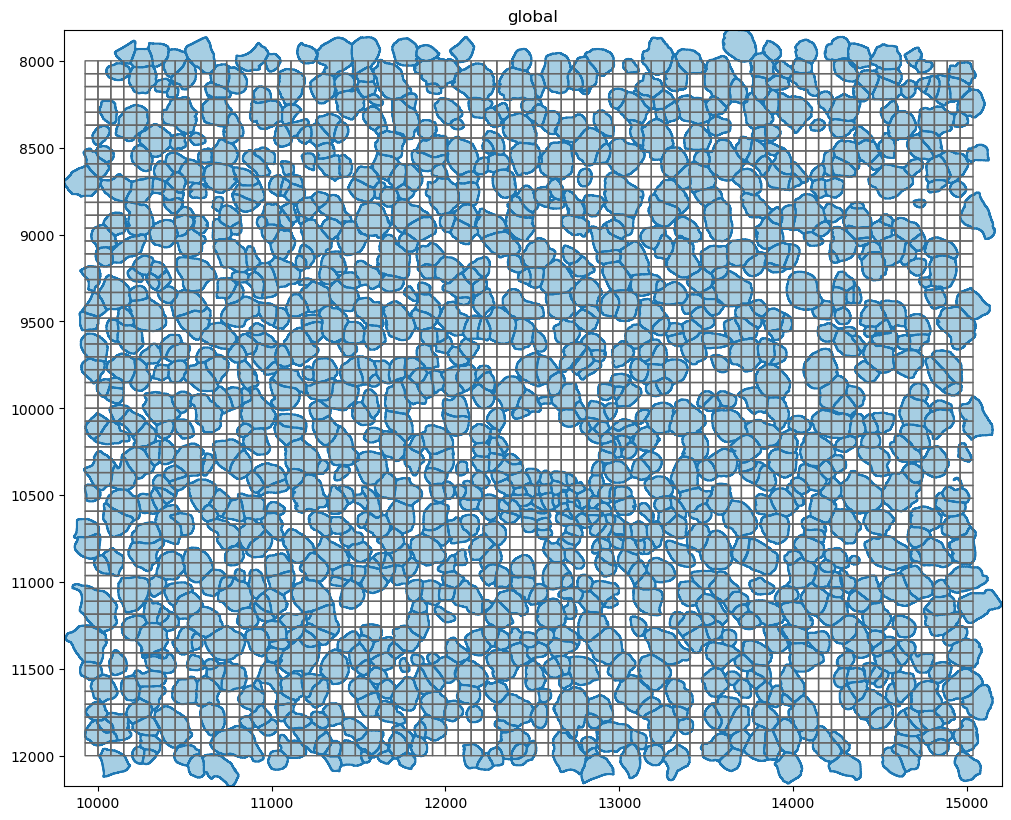

In [5]:
bin_size = 8
sdata_small.pl.render_shapes("to_plot_napari", color="#A6CEE3", outline_alpha=1, outline_color="#1F78B4").pl.render_shapes(f"grid_{bin_size}um", fill_alpha=0, outline_alpha=1, outline_width=1, outline_color="#666666").pl.show(coordinate_systems="global", figsize=(10, 10))

In [ ]:
from shapely.affinity import scale

# Flip the y-coordinates of the geometries in the segmentation_mask_boundaries
flipped_segmentation = sdata_small.shapes['segmentation_mask_boundaries']['geometry'].apply(
    lambda geom: scale(geom, xfact=1, yfact=-1, origin=(0, 0))
)

# Save the flipped geometries to a file
flipped_segmentation.to_file('../visium_hd_liver_combined/vizgen/segmentation_mask_boundaries_roi.shp')

/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/pyogrio/geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [ ]:
from shapely.affinity import scale

for bin_size in [2, 4, 8, 16, 32]:
    # Flip the y-coordinates of the geometries
    flipped_geometry = sdata_small.shapes[f'grid_{bin_size}um']['geometry'].apply(lambda geom: scale(geom, xfact=1, yfact=-1, origin=(0, 0)))
    
    # Save the flipped shapes
    flipped_geometry.to_file(f'../visium_hd_liver_combined/vizgen/grid_{bin_size}um_roi.shp')

### Assigning genes to the simulated 8µm bins (optional)

Instead of assigning transcripts to a segmented cell, we can also assign them to the artificial 8µm bins to and compare the distribution of certain marker genes with those of VisiumHD data. To do this, we have to start again with the transcript coordinates. We use [dask_geopandas](https://dask-geopandas.readthedocs.io/en/stable/) for this which was very annoying to install.

Note that this analysis was not included or mentioned in the chapter. I used the coordinates and expression data to calculate Moran's I of Kupffer cell marker genes in both simulated and real VisiumHD data. The results were not conclusive because the Moran's I of the VisiumHD data could very well be due to sparsity.

In [ ]:
import dask_geopandas

In [6]:
# Extract the points layer as a GeoDataFrame
points = sdata_polyT.points['transcripts']

In [7]:
point_df = dask_geopandas.from_dask_dataframe(points)

In [8]:
point_df = point_df.set_geometry(
    dask_geopandas.points_from_xy(point_df, 'x', 'y')
)

In [9]:
# Extract the grid_8um shape as a GeoDataFrame
grid_8um = sdata_polyT.shapes['grid_8um']

In [10]:
# Perform a spatial join to assign each point to a grid cell
points_in_grid = point_df.sjoin(grid_8um, how='inner', predicate='intersects')


In [11]:
points_in_grid

,x,y,gene,geometry,index_right
npartitions=532,,,,,
,float64,float64,string,geometry,int64
,...,...,...,...,...
...,...,...,...,...,...
,...,...,...,...,...
,...,...,...,...,...


In [15]:
gene_names = ['Sdc3', 'Csf1r', 'Kcnj16']
all(x in sdata_polyT.tables['table'].var_names for x in gene_names)

True

In [16]:
for gene in gene_names[1:]:
    print(gene)
    gene_counts = points_in_grid.query(f'gene == "{gene}"').groupby('index_right').size().compute()
    gene_counts.to_csv(f'../visium_hd_liver_combined/vizgen/vizgen_grid_8um_{gene}_counts.csv')    

Csf1r
Kcnj16
